In [1]:
library(mgcv)
library(ggplot2)
# library(gridExtra)

library(future.apply)
library(future)
library(progressr)

data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'
n_workers<-1
plan(multisession, workers = n_workers)
seed = 888

Loading required package: nlme

This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: future

Warning message:
“package ‘future’ was built under R version 4.5.3”
Warning message:
“package ‘progressr’ was built under R version 4.5.3”


In [2]:
res<-read.csv(file.path(data_path, 'processed', 'pruning_AAD.csv'), row.names = 1)

head(res)

,model_id,connectivity,type,MAE,mean_weight,n_edges
,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>
0,0_0_0,15,stochastic,2.306565e-05,0.01629915,20
1,0_0_1,15,true,1.751534e-05,0.01629915,20
2,0_0_2,15,true,4.777298e-05,0.01629915,20
3,0_0_3,15,true,2.790586e-05,0.01629915,20
4,0_0_4,15,true,1.118388e-05,0.01629915,20
5,0_0_5,15,true,1.314902e-04,0.01629915,20


In [3]:
res$log_MAE <- log(1e-20 + res$MAE)
res$log_connectivity <- log(res$connectivity)
res$log_n_edges <- log(res$n_edges)
res$log_mean_weight <- log(res$mean_weight)
res$type <- as.factor(res$type)
res$model_id <- as.factor(res$model_id)

res$n_edges_resid <- residuals(lm(log_n_edges ~ log_connectivity, data=res)) # due to high concurvity / multi-collinearity of edges with connectivity



# Question 1

Reminder, question 1 is: Do learned weight magnitudes effect AAD independent of topology (while controlling for confounders L2, data_set, and # of edges removed)? 

We'll answer Question 1 with two approaches:

- Approach 1: Fit the GAMM and see whether the mean weight gets a significant p-value
- Approach 2: Use an AIC comparison between the full model and a reduced model where we remove the weight term.The Akaike Information Criterion (AIC) quantifies the tradeoff between model fit and model complexity. Lower AIC indicates a better model.Conceptually, this comparison asks whether including log_mean_weight improves the model’s ability to explain variation in AAD enough to justify the added complexity of the additional smooth term. If the full model has substantially lower AIC than the reduced model, this provides evidence that learned weight magnitudes contribute to AAD independently of topology and other covariates, rather than simply reflecting overfitting.

In [4]:
k_effect = 15

model_full <- gam(log_MAE ~ 
                   s(log_mean_weight, k=k_effect) +    # Weight effect
                   s(log_connectivity, k=k_effect) +        # Topology effect  
                   s(model_id, bs="re") +        # Random intercepts
                  s(n_edges_resid, k=k_effect) +              # Control for no. of zeroed edges
                   type,                         # Fixed effect
                 data=res, 
#                   family = Gamma(link="log"),
                 method="REML")

summary_full <- summary(model_full)
summary_full



Family: gaussian 
Link function: identity 

Formula:
log_MAE ~ s(log_mean_weight, k = k_effect) + s(log_connectivity, 
    k = k_effect) + s(model_id, bs = "re") + s(n_edges_resid, 
    k = k_effect) + type

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -9.9255     0.1385 -71.668   <2e-16 ***
typetrue     -0.1794     0.1453  -1.235    0.217    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                       edf  Ref.df       F  p-value    
s(log_mean_weight)   5.103   6.369   6.859 5.35e-07 ***
s(log_connectivity) 12.704  13.528  50.059  < 2e-16 ***
s(model_id)         36.363 273.000   0.154   0.0467 *  
s(n_edges_resid)     5.980   7.401 111.484  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.354   Deviance explained = 36.4%
-REML = 9755.1  Scale est. = 6.2623    n = 4147

With approach 1, we can see that the weight term has a significant p-value. 


Method: REML   Optimizer: outer newton
full convergence after 8 iterations.
Gradient range [-3.121849e-07,3.811538e-07]
(score 9755.146 & scale 6.262256).
Hessian positive definite, eigenvalue range [0.8460872,2071.181].
Model rank =  319 / 319 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                        k'    edf k-index p-value  
s(log_mean_weight)   14.00   5.10    0.98   0.085 .
s(log_connectivity)  14.00  12.70    0.98   0.080 .
s(model_id)         275.00  36.36      NA      NA  
s(n_edges_resid)     14.00   5.98    0.98   0.160  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Checking for concurvity (similar to multicollinearity):
$worst
                            para s(log_mean_weight) s(log_connectivity)
para                1.000000e+00       4.455280e-24        8.588520e-24
s(log_mean_weight)  4.448551e-24       1.000000e+00        5.182662e-01
s(log_connectivi

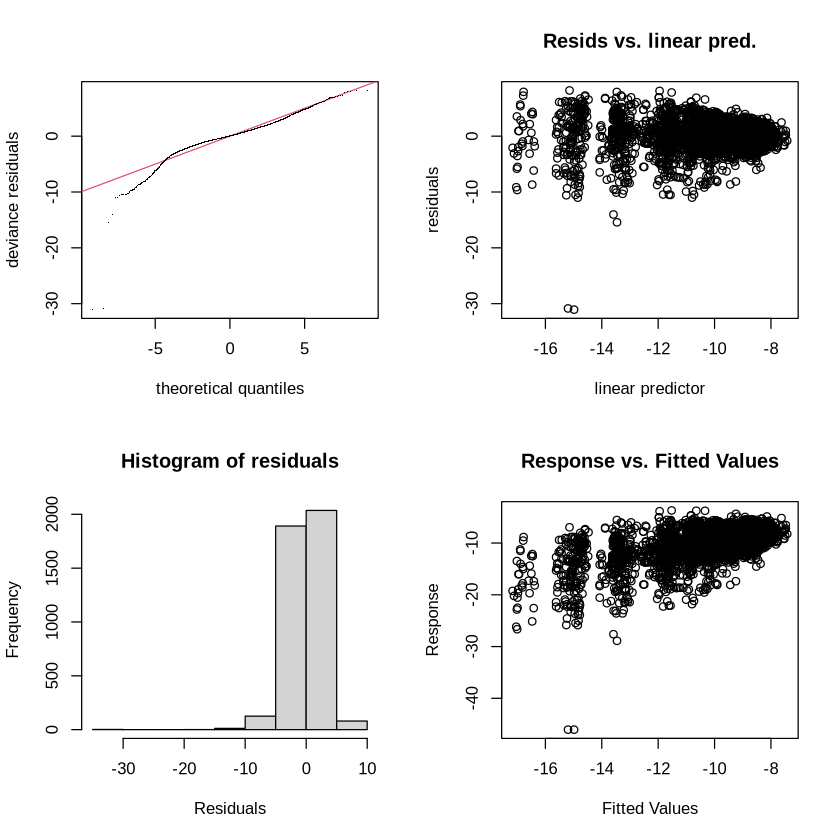

In [5]:
par(mfrow=c(2,2))
gam.check(model_full)

cat("\nChecking for concurvity (similar to multicollinearity):\n")
print(concurvity(model_full, full=FALSE))
cat("\nValues close to 1 indicate problematic concurvity.\n")
cat("Values < 0.8 are generally acceptable.\n")

In [5]:
# fit with ML for comparison
model_full_ml <- gam(log_MAE ~ 
                   s(log_mean_weight, k=k_effect) +
                   s(log_connectivity, k=k_effect) +      
                   s(model_id, bs="re") +      
                   s(n_edges_resid, k=k_effect) +           
                   type,
                 data = res,
                 method = "ML")

model_reduced_ml <- gam(log_MAE ~ 
                   s(log_connectivity, k=k_effect) +      
                   s(model_id, bs="re") +      
                   s(n_edges_resid, k=k_effect) +           
                   type,
                 data = res,
                 method = "ML")


# AIC comparison
aic_res <- AIC(model_reduced_ml, model_full_ml)

aic_reduced <- aic_res["model_reduced_ml", "AIC"]
aic_full    <- aic_res["model_full_ml", "AIC"]
delta_aic   <- aic_reduced - aic_full   # positive => full better

print(aic_res)

cat(sprintf(
  "\nAIC comparison:\nReduced model AIC = %.2f\nFull model AIC = %.2f\nDelta AIC = %.2f\n",
  aic_reduced, aic_full, delta_aic
))

if (delta_aic < 2) {
  interp <- "Models have equivalent support."
} else if (delta_aic < 7) {
  interp <- "Weight provides modest additional explanatory value."
} else if (delta_aic < 10) {
  interp <- "Weight clearly improves model fit."
} else {
  interp <- "Weight strongly improves model fit, indicating an independent contribution beyond topology and controls."
}

cat(sprintf("Interpretation: %s\n", interp))

                       df      AIC
model_reduced_ml 68.03720 19487.03
model_full_ml    69.20702 19457.13

AIC comparison:
Reduced model AIC = 19487.03
Full model AIC = 19457.13
Delta AIC = 29.90
Interpretation: Weight strongly improves model fit, indicating an independent contribution beyond topology and controls.


In [7]:
# model_full_ml <- gam(log_MAE ~ 
#                    s(log_mean_weight, k=k_effect) +
#                    s(log_connectivity, k=k_effect) +      
#                    s(model_id, bs="re") +      
#                    s(n_edges_resid, k=k_effect) +           
#                    type,
#                  data = res,
#                  method = "ML")

# model_no_weight_ml <- gam(log_MAE ~ 
#                    s(log_connectivity, k=k_effect) +      
#                    s(model_id, bs="re") +      
#                    s(n_edges_resid, k=k_effect) +           
#                    type,
#                  data = res,
#                  method = "ML")

# model_no_connectivity_ml <- gam(log_MAE ~ 
#                    s(log_mean_weight, k=k_effect) +      
#                    s(model_id, bs="re") +      
#                    s(n_edges_resid, k=k_effect) +           
#                    type,
#                  data = res,
#                  method = "ML")

# aic_res <- AIC(
#   model_full_ml,
#   model_no_weight_ml,
#   model_no_connectivity_ml
# )

# print(aic_res)


# # delta AICs
# aic_full <- aic_res["model_full_ml", "AIC"]
# aic_no_weight <- aic_res["model_no_weight_ml", "AIC"]
# aic_no_connectivity <- aic_res["model_no_connectivity_ml", "AIC"]

# delta_weight <- aic_no_weight - aic_full
# delta_connectivity <- aic_no_connectivity - aic_full

# # interpret
# cat(sprintf(
#   "\nDelta AIC (removing weight): %.2f\nDelta AIC (removing connectivity): %.2f\n",
#   delta_weight, delta_connectivity
# ))

# if (delta_weight > delta_connectivity) {
#   cat("Interpretation: Removing weight worsens model fit more than removing connectivity, indicating weight has greater independent utility.\n")
# } else if (delta_connectivity > delta_weight) {
#   cat("Interpretation: Removing connectivity worsens model fit more than removing weight, indicating connectivity has greater independent utility.\n")
# } else {
#   cat("Interpretation: Weight and connectivity contribute similarly to model fit.\n")
# }

In [8]:
# # remove the weight term
# model_reduced <- gam(log_MAE ~ 
#                    s(log_connectivity, k=k_effect) +        # Topology effect  
#                    s(model_id, bs="re") +        # Random intercepts
#                   s(n_edges_resid, k=k_effect) +              # Control for no. of zeroed edges
#                    type,                         # Fixed effect
#                  data=res, 
# #                   family = Gamma(link="log"),
#                  method="REML")

# aic_res <- AIC(model_reduced, model_full_lrt)

# # extract values
# aic_reduced <- aic_res["model_reduced", "AIC"]
# aic_full <- aic_res["model_full", "AIC"]
# delta_aic <- aic_reduced - aic_full   # positive => full model better

# # print table
# print(aic_res)

# # print interpretation
# cat(sprintf(
#   "\nAIC comparison:\nReduced model AIC = %.2f\nFull model AIC = %.2f\nDelta AIC (reduced - full) = %.2f\n",
#   aic_reduced, aic_full, delta_aic
# ))

# if (delta_aic < 2) {
#   interp <- "The models have essentially equivalent support."
# } else if (delta_aic < 7) {
#   interp <- "The full model has modestly better support."
# } else if (delta_aic < 10) {
#   interp <- "The full model has clearly better support."
# } else {
#   interp <- "The full model is strongly preferred, indicating that log_mean_weight improves model fit beyond the penalty for added complexity."
# }

# cat(sprintf("Interpretation: %s\n", interp))

In [9]:
# # summaries
# summ_full <- summary(model_full_ml)
# summ_no_weight <- summary(model_no_weight_ml)
# summ_no_connectivity <- summary(model_no_connectivity_ml)

# # print baseline values
# cat(sprintf("Full model:             R² = %.4f, Deviance explained = %.2f%%\n",
#             summ_full$r.sq, summ_full$dev.expl * 100))

# cat(sprintf("Without weight:         R² = %.4f, Deviance explained = %.2f%%\n",
#             summ_no_weight$r.sq, summ_no_weight$dev.expl * 100))

# cat(sprintf("Without connectivity:   R² = %.4f, Deviance explained = %.2f%%\n",
#             summ_no_connectivity$r.sq, summ_no_connectivity$dev.expl * 100))


# # improvements relative to reduced models
# dev_imp_weight <- (summ_full$dev.expl - summ_no_weight$dev.expl) * 100
# r2_imp_weight  <- summ_full$r.sq - summ_no_weight$r.sq

# dev_imp_conn <- (summ_full$dev.expl - summ_no_connectivity$dev.expl) * 100
# r2_imp_conn  <- summ_full$r.sq - summ_no_connectivity$r.sq


# cat("\nImprovement from adding weight:\n")
# cat(sprintf("  Deviance explained: +%.2f percentage points\n", dev_imp_weight))
# cat(sprintf("  R²: +%.4f\n", r2_imp_weight))

# cat("\nImprovement from adding connectivity:\n")
# cat(sprintf("  Deviance explained: +%.2f percentage points\n", dev_imp_conn))
# cat(sprintf("  R²: +%.4f\n", r2_imp_conn))


# # relative comparison
# cat("\nRelative importance:\n")
# if (dev_imp_conn > dev_imp_weight) {
#   cat("  Connectivity explains more additional deviance than weight.\n")
# } else if (dev_imp_weight > dev_imp_conn) {
#   cat("  Weight explains more additional deviance than connectivity.\n")
# } else {
#   cat("  Weight and connectivity contribute similarly.\n")
# }

# GAM Model Comparison: Notes on Weight vs. Connectivity Effects

## 1. Model Fit Comparison: AIC and Deviance

To assess the independent contribution of edge weight and connectivity, we compared three models using AIC and deviance explained:

| Model | df | AIC | Deviance Explained | R² |
|---|---|---|---|---|
| Full (weight + connectivity) | 69.21 | 19457.13 | 36.38% | 0.3543 |
| No weight | 68.04 | 19487.03 | 35.87% | 0.3489 |
| No connectivity | 41.81 | 20068.33 | — | — |

**Delta AIC (removing weight):** +29.90 — moderate but robust penalty, indicating edge weight contributes independently to model fit beyond topology and batch size effects.

**Delta AIC (removing connectivity):** +611.20 — a very large penalty, indicating connectivity is the dominant predictor of MAE in this framework.

**Delta deviance explained (removing weight):** −0.51 percentage points — statistically robust (ΔAIC = 29.9) but practically modest, suggesting weight is a real but secondary driver of prediction error relative to network topology.

---

## 2. Why We Retained `n_edges` Despite the Unexpected Negative Connectivity Partial Effect

In the full model, the partial effect curve for `log_connectivity` showed an unexpected **negative** relationship with `log_MAE` — the opposite of our theoretical expectation that higher-connectivity edges would be harder to predict and thus produce higher MAE.

To investigate whether this sign flip was driven by the concurvity with `n_edges`, we fitted a model excluding it entirely:

- Removing `n_edges` did improve the apparent contribution of weight (marginally higher ΔAIC and deviance explained for the weight term).
- However, the **negative partial effect of connectivity persisted** even without `n_edges` in the model, indicating the sign flip is not solely an artefact of including batch size.
- More critically, excluding `n_edges` produces a **misspecified model**: the number of edges removed per degree bin is a structural feature of the removal procedure and an independent source of variation in MAE. Omitting it conflates the effect of connectivity with uncontrolled variation in removal batch size, making comparisons between weight and connectivity unfair.

We therefore retained `n_edges` (as its residual after orthogonalisation against connectivity; see below) and interpret the connectivity partial effect with appropriate caution.

---

## 3. Why Relative Importance of Weight vs. Connectivity Cannot Be Cleanly Estimated

A core inferential goal was to quantify the relative contribution of edge weight versus network connectivity to prediction error. However, this comparison is not fully identifiable given the structure of the data, for the following reasons.

### Structural collinearity by design

The degree-bin removal procedure creates an inherent correlation between connectivity and batch size: higher-connectivity degree bins contain more edges and therefore yield larger removal batches. This means `log_connectivity` and `log_n_edges` are correlated **by construction**, not by accident.

### Residualisation does not fully resolve the problem

To address concurvity (worst-case value = 0.95 between `log_connectivity` and `log_n_edges`), we orthogonalised batch size against connectivity by replacing `log_n_edges` with its residual from the regression:

```r
res$n_edges_resid <- residuals(lm(log_n_edges ~ log_connectivity, data = res))
```

This reduces but does not eliminate the shared variance, because the relationship between `log_n_edges` and `log_connectivity` is not perfectly linear — the residual retains some connectivity signal. As a consequence:

- The model partitions one underlying positive effect into two components with partially opposing signs, an artefact of collinearity rather than a true mechanistic signal.
- The ΔAIC when dropping connectivity (611.2) reflects both its true effect *and* the fact that `n_edges_resid` was constructed relative to connectivity and cannot compensate for its removal — likely **inflating** the apparent importance of connectivity relative to weight.

### What can be stated

- The **unique contribution of edge weight** (ΔAIC = 29.9, holding all other terms constant) is the cleanest and most conservative estimate available, and is not materially affected by the connectivity/n_edges collinearity.
- The **joint contribution of weight and connectivity together** can be estimated cleanly by comparing the full model to one containing only `n_edges_resid` and the random effect.
- The **ratio of connectivity to weight importance** is not reliably estimable and should not be reported as a precise quantity.

We therefore focus on establishing that edge weight has a statistically robust independent effect on MAE, while acknowledging that the dominant role of network topology cannot be precisely decomposed from batch size effects given the current experimental design.


# Question 2

Reminder: What kind of effect do learned weight magnitudes, edge connectivity, and removed edge type (stochastic vs true) have on AAD?

This is just visualizing the effect from the fitted full model

In [6]:
plot_gam_effects_1x3 <- function(
  model_full,
  w = 10, h = 3.5,
  
  axis_cex = 1.2,
  label_cex = 1.6,
  base_cex = 1.2,
  
  mar_vec = c(6, 5.5, 1.5, 0.8),
  
  lwd = 2,
  save_path = NULL,
  dpi = 600
) {
  
  blue_est  <- "#1f77b4"
  gray_zero <- "gray60"

  if (!is.null(save_path)) {
    grDevices::png(
      filename = save_path,
      width = w, height = h, units = "in",
      res = dpi, type = "cairo", bg = "transparent"
    )
    on.exit(grDevices::dev.off(), add = TRUE)
  }

  op <- par(no.readonly = TRUE)
  on.exit(par(op), add = TRUE)

  par(
    mfrow = c(1, 3),
    mar = c(5.2, 4.2, 1.2, 0.3),
    cex = base_cex,
    cex.axis = axis_cex
  )

  ylab_txt <- "log(AAD)" # "log(MAE)"

  # 👇 add x_line argument
  plot_panel <- function(select_idx, xlab_txt, x_line = 2.5) {
    mgcv::plot.gam(
      model_full, select = select_idx,
      se = TRUE,
      col = blue_est, lwd = lwd,
      xlab = "", ylab = "",
      rug = FALSE,
      residuals = FALSE
    )
    abline(h = 0, col = gray_zero, lwd = 1)
    
    mtext(xlab_txt, side = 1, line = x_line, cex = label_cex)
    mtext(ylab_txt, side = 2, line = 2.5, cex = label_cex)
  }

  # panels
  plot_panel(1, "log(Mean |Edge Weight|)")
  plot_panel(2, "log(Edge Connectivity)")
  plot_panel(4, "Residualized\nlog(No. Removed Edges)", x_line = 3.5)  # 👈 only change here

  invisible(NULL)
}

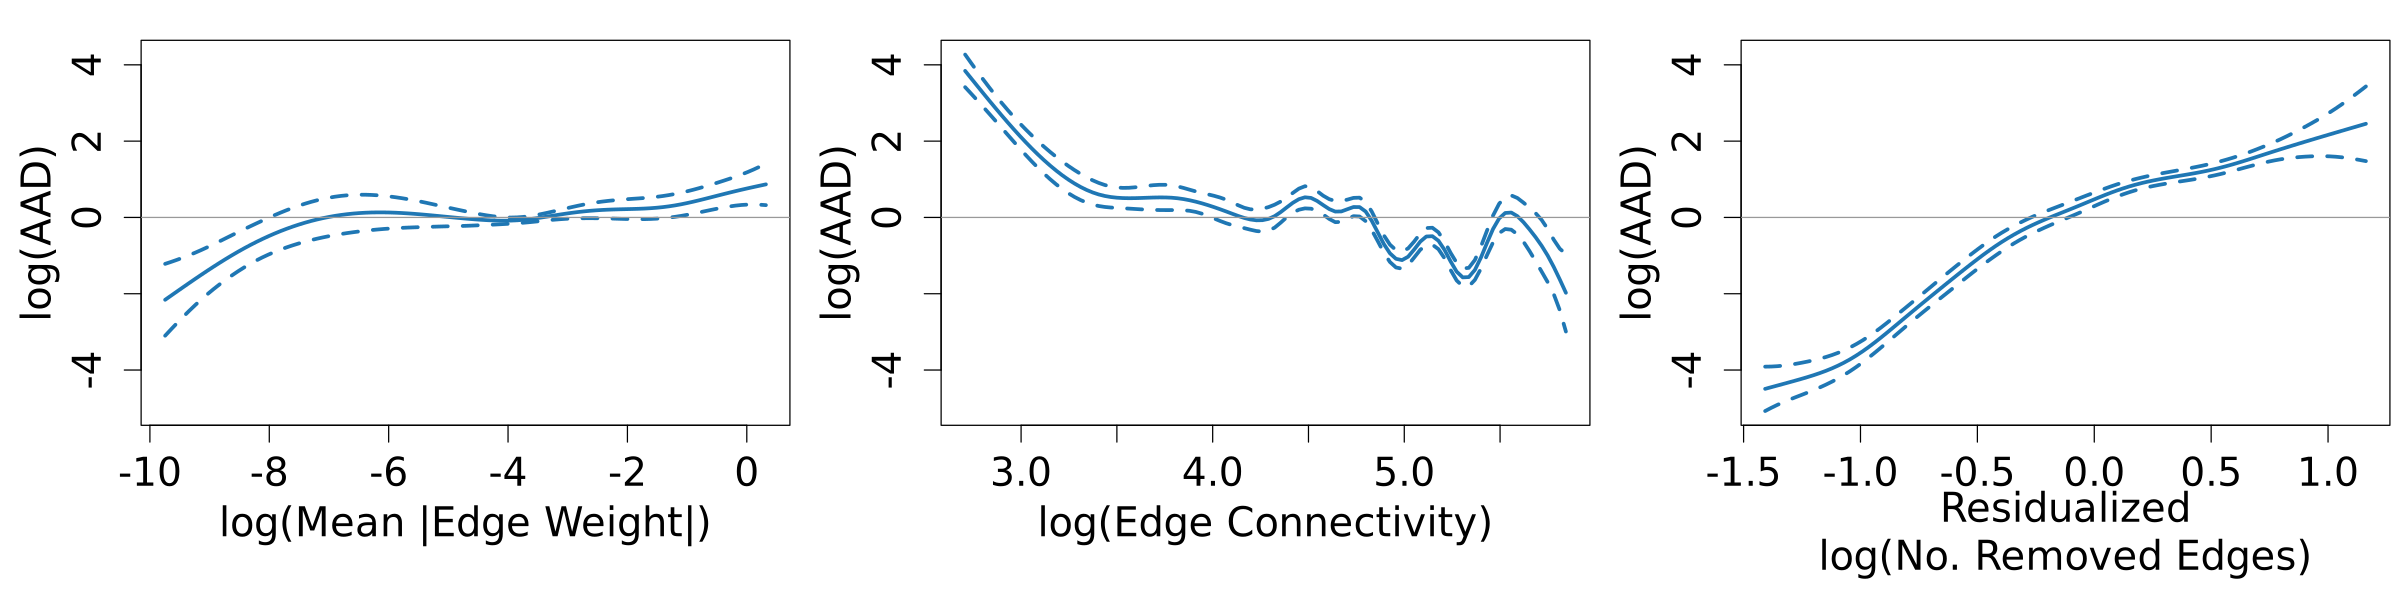

In [7]:
w = 20
h = 5
options(repr.plot.width = w, repr.plot.height = h)

# save
plot_gam_effects_1x3(
  model_full,
  w = w, h = h,
  base_cex = 1.4,
  axis_cex = 1.4,
  label_cex = 2,
    lwd       = 3,
  save_path = file.path(data_path,'figures', "McCauley_selfpruning_GAM_partial_effects.png"),
  dpi = 600
)

# display
plot_gam_effects_1x3(
  model_full,
  w = w, h = h,
  base_cex = 1.4,
  axis_cex = 1.4,
  label_cex = 2,
    lwd       = 3,
  save_path = NULL
)

In [8]:
file.path(data_path,'figures', "McCauley_selfpruning_GAM_partial_effects.png")

[1] "/home/hmbaghda/orcd/pool/scLEMBAS/analysis/figures/McCauley_selfpruning_GAM_partial_effects.png"

# Effect of Real vs Spurious Edges

In [12]:
type_coef <- coef(model_full)["typetrue"]  # Assuming 'stochastic' is reference
type_se <- summary(model_full)$p.table["typetrue", "Std. Error"]
type_pval <- summary(model_full)$p.table["typetrue", "Pr(>|t|)"]

cat(sprintf("Coefficient: %.4f (SE = %.4f, p = %.4f)\n", type_coef, type_se, type_pval))
cat(sprintf("\nInterpretation: Zeroing TRUE edges changes AAD by %.4f units\n", type_coef))
cat(sprintf("compared to zeroing STOCHASTIC edges (holding all else constant).\n"))

if (type_coef > 0) {
  cat("Direction: Removing true edges INCREASES AAD relative to stochastic edges.\n")
} else {
  cat("Direction: Removing true edges DECREASES AAD relative to stochastic edges.\n")
}

Coefficient: -0.1794 (SE = 0.1453, p = 0.2168)

Interpretation: Zeroing TRUE edges changes AAD by -0.1794 units
compared to zeroing STOCHASTIC edges (holding all else constant).
Direction: Removing true edges DECREASES AAD relative to stochastic edges.


This indicates that, conditional on edge weight, connectivity, number of edges removed, and other covariates, removing TRUE edges produces a smaller deviation from the baseline prediction than removing stochastic edges. While this may appear counterintuitive, it may reflect the fact that this comparison is made after controlling for edge weight, and we have already shown that TRUE edges tend to have larger learned weights.

Let's test this a bit further. We can compare it to a model that includes an interaction between edge weight and edge type. 

In [13]:
# model_full2 <- gam(
#   MAE ~
#     type +                          
#     s(log_mean_weight, by = type, k=k_effect) +
#     s(connectivity, k=k_effect) +
#     s(n_edges, k=k_effect) +
#     data_set + L2 +
#     s(model_id, bs="re"),
#   data = res,
#   method = "REML"
# )

# summary(model_full2)

In [14]:
model_full2 <- gam(log_MAE ~ 
                   type + # still a fixed effect
                   s(log_mean_weight, by = type, k=k_effect) +    # Weight effect
                   s(log_connectivity, k=k_effect) +        # Topology effect  
                   s(model_id, bs="re") +        # Random intercepts
                  s(n_edges_resid, k=k_effect),              # Control for no. of zeroed edges
                 data=res, 
#                   family = Gamma(link="log"),
                 method="REML")
summary(model_full2)


Family: gaussian 
Link function: identity 

Formula:
log_MAE ~ type + s(log_mean_weight, by = type, k = k_effect) + 
    s(log_connectivity, k = k_effect) + s(model_id, bs = "re") + 
    s(n_edges_resid, k = k_effect)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -9.9267     0.1359 -73.032   <2e-16 ***
typetrue     -0.1781     0.1426  -1.249    0.212    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                                     edf  Ref.df       F p-value    
s(log_mean_weight):typestochastic  3.566   4.470  46.517 < 2e-16 ***
s(log_mean_weight):typetrue        5.589   6.942   3.433 0.00117 ** 
s(log_connectivity)               12.749  13.553  51.860 < 2e-16 ***
s(model_id)                       37.976 273.000   0.162 0.03868 *  
s(n_edges_resid)                   6.063   7.499 114.576 < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq

In [15]:
model_full_lrt <- gam(log_MAE ~ 
                   s(log_mean_weight, k=k_effect) +    # Weight effect
                   s(log_connectivity, k=k_effect) +        # Topology effect  
                   s(model_id, bs="re") +        # Random intercepts
                  s(n_edges_resid, k=k_effect) +              # Control for no. of zeroed edges
                   type,                         # Fixed effect
                 data=res, 
#                   family = Gamma(link="log"),
                 method="ML")

model_full2_lrt <- gam(log_MAE ~ 
                   type + # still a fixed effect
                   s(log_mean_weight, by = type, k=k_effect) +    # Weight effect
                   s(log_connectivity, k=k_effect) +        # Topology effect  
                   s(model_id, bs="re") +        # Random intercepts
                  s(n_edges_resid, k=k_effect),              # Control for no. of zeroed edges
                 data=res, 
#                   family = Gamma(link="log"),
                 method="ML")

# in this case, model_full_lrt is the reduced model relative to model_full2_lrt
anova(model_full_lrt, model_full2_lrt, test="Chisq")


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4044.775,25610.16,NA,NA,NA
2,4037.262,24464.50,7.513128,1145.657,2.085655e-37


Given that this LRT is significant, it means the relationship between learned edge weight magnitude and prediction deviation differs between TRUE and stochastic edges. In other words, allowing the weight–AAD effect to vary by edge type provides a significantly better explanation of the data than a single shared weight effect, indicating type-specific mechanistic differences in how learned interaction strengths influence model sensitivity.

In [17]:
# options(repr.plot.width = 7, repr.plot.height = 5)

# # grid over weight
# w_grid <- seq(min(res$log_mean_weight),
#               max(res$log_mean_weight),
#               length.out = 200)

# # helper
# mode_level <- function(x) {
#   tab <- table(x)
#   names(tab)[which.max(tab)]
# }

# # baseline row
# base <- res[1, , drop = FALSE]
# base$log_connectivity <- median(res$log_connectivity, na.rm = TRUE)
# base$n_edges_resid    <- median(res$n_edges_resid, na.rm = TRUE)

# base$type     <- factor(mode_level(res$type), levels = levels(res$type))
# base$model_id <- factor(mode_level(res$model_id), levels = levels(res$model_id))

# # predictions by type
# pred_by_type <- lapply(c("stochastic", "true"), function(tp) {
#   nd <- base[rep(1, length(w_grid)), ]
#   nd$log_mean_weight <- w_grid
#   nd$type <- factor(tp, levels = levels(res$type))

#   pr <- predict(model_full2,
#                 newdata = nd,
#                 se.fit = TRUE,
#                 exclude = "s(model_id)")

#   data.frame(w = w_grid, fit = pr$fit, se = pr$se.fit, type = tp)
# })

# dfp <- do.call(rbind, pred_by_type)

# # plot
# plot(NULL,
#      xlim = range(dfp$w),
#      ylim = range(c(dfp$fit - 2*dfp$se, dfp$fit + 2*dfp$se)),
#      xlab = "log(Mean |Edge Weight|)",
#      ylab = "log(AAD)")

# cols <- c(stochastic = "#ff7f0e", true = "#1f77b4")

# for (tp in names(cols)) {
#   d <- dfp[dfp$type == tp, ]
#   lines(d$w, d$fit, col = cols[tp], lwd = 2)
#   lines(d$w, d$fit + 2*d$se, col = cols[tp], lty = 2)
#   lines(d$w, d$fit - 2*d$se, col = cols[tp], lty = 2)
# }

# abline(h = 0, col = "gray60", lwd = 2)

# legend("topleft",
#        legend = c("True Edges", "Stochastic Edges"),
#        col = cols[c("true","stochastic")],
#        lwd = 2,
#        bty = "n")

In [22]:
# Get predictions at fine grid (already have dfp)
# Add percentile bin based on weight position in the OBSERVED distribution
breaks_5 <- quantile(res$log_mean_weight, probs = seq(0, 1, 0.05))
bin_mids <- (breaks_5[-21] + breaks_5[-1]) / 2

# For each bin midpoint, find nearest prediction in dfp
get_bin_stats <- function(type_label) {
  d <- dfp[dfp$type == type_label, ]
  lapply(seq_along(bin_mids), function(i) {
    # find closest point in prediction grid to bin midpoint
    idx <- which.min(abs(d$w - bin_mids[i]))
    data.frame(
      ventile     = i,
      pct         = i * 5,
      w_mid       = bin_mids[i],
      fit         = d$fit[idx],
      lower       = d$fit[idx] - 2 * d$se[idx],
      upper       = d$fit[idx] + 2 * d$se[idx],
      ci_width    = 4 * d$se[idx],  # total width of ±2SE band
      type        = type_label
    )
  }) |> do.call(what = rbind)
}

bin_stats <- rbind(get_bin_stats("true"), get_bin_stats("stochastic"))

# Now check overlap within each bin
overlap_check <- do.call(rbind, lapply(unique(bin_stats$ventile), function(v) {
  tr <- bin_stats[bin_stats$ventile == v & bin_stats$type == "true", ]
  st <- bin_stats[bin_stats$ventile == v & bin_stats$type == "stochastic", ]
  
  # Intervals overlap if lower of one is below upper of other
  overlaps <- tr$lower <= st$upper & st$lower <= tr$upper
  
  data.frame(
    ventile       = v,
    pct           = v * 5,
    w_mid         = tr$w_mid,
    fit_true      = tr$fit,
    fit_stoch     = st$fit,
    ci_width_true = tr$ci_width,
    ci_width_stoch= st$ci_width,
    overlap       = overlaps
  )
}))

overlap_check

ventile,pct,w_mid,fit_true,fit_stoch,ci_width_true,ci_width_stoch,overlap
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,5,-7.6005938,-8.915987,-12.664861,1.2677703,2.5271649,FALSE
2,10,-5.0086155,-8.812818,-10.975353,0.8018481,1.4116280,FALSE
3,15,-4.4299650,-8.963758,-10.300357,0.6713396,1.0437730,FALSE
4,20,-4.2485931,-9.018543,-9.997081,0.6485443,0.9494981,FALSE
5,25,-4.1586498,-9.031244,-9.916685,0.6448377,0.9309565,FALSE
6,30,-4.0841276,-9.054446,-9.750883,0.6396702,0.9006935,TRUE
7,35,-4.0193095,-9.064619,-9.665644,0.6382126,0.8891794,TRUE
8,40,-3.9530763,-9.081350,-9.490943,0.6372215,0.8733385,TRUE
9,45,-3.8835980,-9.087671,-9.401667,0.6374302,0.8687559,TRUE


Sanity check: compare to true partial effect (vs fixing other covarites to their median):

Warning message:
“The `smooth` argument of `smooth_estimates()` is deprecated as of gratia
0.8.9.9.
ℹ Please use the `select` argument instead.”


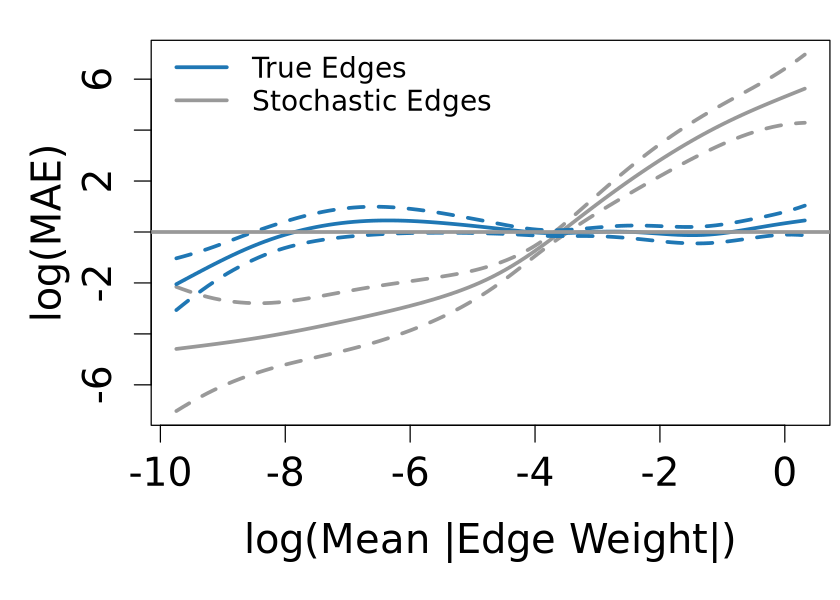

In [19]:
library(gratia)

pe <- smooth_estimates(model_full2,
                       smooth = c("s(log_mean_weight):typestochastic",
                                  "s(log_mean_weight):typetrue"),
                       ci_level = 0.95)

dfp_partial <- data.frame(
  w    = pe$log_mean_weight,
  fit  = pe$.estimate,
  se   = pe$.se,
  type = pe$type
)

# --- styling to match the 1x3 GAM plot ---
base_cex  <- 1.4
axis_cex  <- 1.4
label_cex <- 2
lwd       <- 3

op <- par(no.readonly = TRUE)
on.exit(par(op), add = TRUE)
par(
  cex      = base_cex,   # scales everything, incl. tick labels & legend
  cex.axis = axis_cex,   # tick-label size (× base_cex)
  mar      = c(5.2, 4.5, 1.2, 0.3)  # widen if titles/labels collide
)

# empty labels here; draw them with mtext at label_cex
plot(NULL,
     xlim = range(dfp_partial$w),
     ylim = range(c(dfp_partial$fit - 2*dfp_partial$se,
                    dfp_partial$fit + 2*dfp_partial$se)),
     xlab = "", ylab = "")

mtext("log(Mean |Edge Weight|)",     side = 1, line = 3.0, cex = label_cex)
mtext("log(MAE)",  side = 2, line = 2.5, cex = label_cex)

cols <- c(stochastic = "#999999", true = "#1f77b4")

for (tp in names(cols)) {
  d <- dfp_partial[dfp_partial$type == tp, ]
  lines(d$w, d$fit,          col = cols[tp], lwd = lwd)
  lines(d$w, d$fit + 2*d$se, col = cols[tp], lwd = lwd, lty = 2)
  lines(d$w, d$fit - 2*d$se, col = cols[tp], lwd = lwd, lty = 2)
}

abline(h = 0, col = "gray60", lwd = lwd)

legend("topleft",
       legend   = c("True Edges", "Stochastic Edges"),
       col      = cols[c("true", "stochastic")],
       lwd      = lwd,
       bty      = "n",
       y.intersp = 1.6) 

pdf 
  2

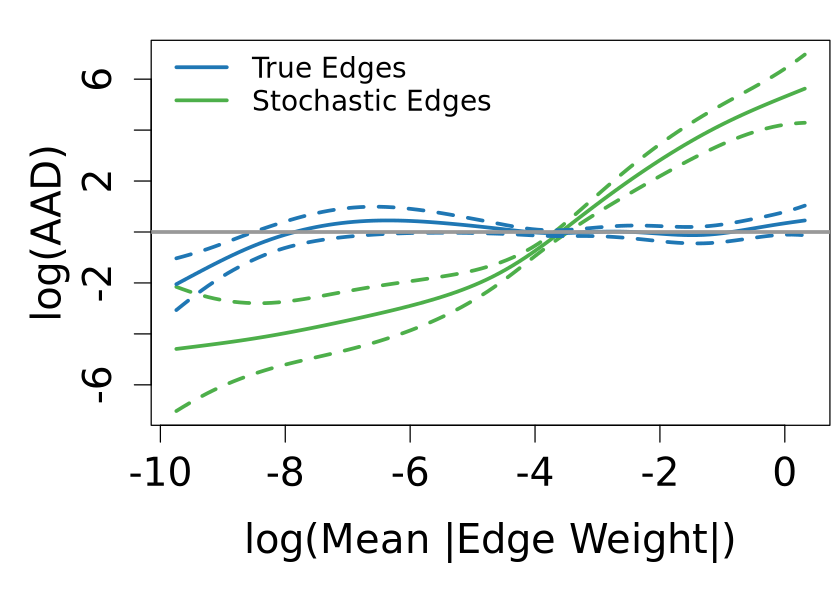

In [21]:
library(gratia)

cols <- c(stochastic = "#4daf4a", true = "#1f77b4")
draw_plot <- function() {
  par(
    cex      = base_cex,
    cex.axis = axis_cex,
    mar      = c(5.2, 4.5, 1.2, 0.3)
  )

  plot(NULL,
       xlim = range(dfp_partial$w),
       ylim = range(c(dfp_partial$fit - 2*dfp_partial$se,
                      dfp_partial$fit + 2*dfp_partial$se)),
       xlab = "", ylab = "")

  mtext("log(Mean |Edge Weight|)",    side = 1, line = 3.0, cex = label_cex)
  mtext("log(AAD)", side = 2, line = 2.5, cex = label_cex)

  for (tp in names(cols)) {
    d <- dfp_partial[dfp_partial$type == tp, ]
    lines(d$w, d$fit,          col = cols[tp], lwd = lwd)
    lines(d$w, d$fit + 2*d$se, col = cols[tp], lwd = lwd, lty = 2)
    lines(d$w, d$fit - 2*d$se, col = cols[tp], lwd = lwd, lty = 2)
  }

  abline(h = 0, col = "gray60", lwd = lwd)

  legend("topleft",
         legend    = c("True Edges", "Stochastic Edges"),
         col       = cols[c("true", "stochastic")],
         lwd       = lwd,
         bty       = "n",
         y.intersp = 1.6)
}

w <- 7; h <- 5

# 1) save to PNG
png(
  filename = file.path(data_path, "figures", "McCauley_partial_effects_bytype.png"),
  width = w, height = h, units = "in",
  res = 600, type = "cairo", bg = "transparent"
)
draw_plot()
dev.off()

# 2) display in session / notebook
options(repr.plot.width = w, repr.plot.height = h)  # notebook sizing
draw_plot()

In [31]:
# Get predictions at fine grid (using partial effects)
breaks_5 <- quantile(res$log_mean_weight, probs = seq(0, 1, 0.05))
bin_mids <- (breaks_5[-21] + breaks_5[-1]) / 2

get_bin_stats_partial <- function(type_label) {
  d <- dfp_partial[dfp_partial$type == type_label, ]
  lapply(seq_along(bin_mids), function(i) {
    idx <- which.min(abs(d$w - bin_mids[i]))
    data.frame(
      ventile  = i,
      pct      = i * 5,
      w_mid    = bin_mids[i],
      fit      = d$fit[idx],
      lower    = d$fit[idx] - 2 * d$se[idx],
      upper    = d$fit[idx] + 2 * d$se[idx],
      ci_width = 4 * d$se[idx],
      type     = type_label
    )
  }) |> do.call(what = rbind)
}

bin_stats_partial <- rbind(get_bin_stats_partial("true"), 
                           get_bin_stats_partial("stochastic"))

overlap_check_partial <- do.call(rbind, lapply(unique(bin_stats_partial$ventile), function(v) {
  tr <- bin_stats_partial[bin_stats_partial$ventile == v & bin_stats_partial$type == "true", ]
  st <- bin_stats_partial[bin_stats_partial$ventile == v & bin_stats_partial$type == "stochastic", ]
  
  overlaps <- tr$lower <= st$upper & st$lower <= tr$upper
  
  data.frame(
    ventile        = v,
    pct            = v * 5,
    w_mid          = tr$w_mid,
    fit_true       = tr$fit,
    fit_stoch      = st$fit,
    ci_width_true  = tr$ci_width,
    ci_width_stoch = st$ci_width,
    overlap        = overlaps
  )
}))

overlap_check_partial

ventile,pct,w_mid,fit_true,fit_stoch,ci_width_true,ci_width_stoch,overlap
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,5,-7.6005938,0.141559861,-3.78585675,1.0722663,2.3819930,FALSE
2,10,-5.0086155,0.232889876,-2.07701981,0.5467484,1.1509584,FALSE
3,15,-4.4299650,0.094766226,-1.46058232,0.3461694,0.7078500,FALSE
4,20,-4.2485931,0.039224005,-1.15930952,0.2838027,0.5498385,FALSE
5,25,-4.1586498,0.013794952,-0.99754957,0.2597437,0.4820218,FALSE
6,30,-4.0841276,-0.008522910,-0.82911644,0.2420466,0.4261801,FALSE
7,35,-4.0193095,-0.008522910,-0.82911644,0.2420466,0.4261801,FALSE
8,40,-3.9530763,-0.026428901,-0.65471177,0.2317587,0.3867570,FALSE
9,45,-3.8835980,-0.038885717,-0.47508835,0.2273831,0.3659495,FALSE


In [32]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 8.10 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /orcd/pool/005/hmbaghda/miniforge3/envs/GAMM_R/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] gratia_0.11.2       progressr_0.19.0    future.apply_1.20.2
[4] future_1.70.0       ggplot2_4.0.2       mgcv_1.9-4         
[7] nlme_3.1-168       

loaded via a namespace (and not attached):
 [1] gen